# use_nbhood 官方数据对比

本 notebook 读取 `nbhood/resource/official_test_use_nohood` 中的官方输入、辅助数据、官方 KGO 和原算法输出，调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 进行处理，并绘制辅助数据图与结果对比图。

## 1. 环境与参数

这里完成依赖导入、路径定位和本次 use_nbhood 对比使用的统一参数设置。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 支持从 notebook 所在目录运行，也支持从工程根目录启动 Jupyter 后运行。
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR.parent / "test_data" / "official_test_use_nbhood").exists():
    NOTEBOOK_DIR = Path(r"D:\workspace\improver\nbhood\nbs")

PROJECT_DIR = NOTEBOOK_DIR.parent
ROOT_DIR = NOTEBOOK_DIR.parents[1] #项目根目录
RESOURCE_DIR = PROJECT_DIR / "test_data" / "official_test_use_nbhood"
sys.path.insert(0, str(ROOT_DIR))

from nbhood.src.use_nbhood import ApplyNeighbourhoodProcessingWithAMask

COORD_FOR_MASKING = "topographic_zone"
RADIUS_METRES = 10000.0
THRESHOLD_INDEX = 0
BAND_INDEX = 1
FILL_THRESHOLD = 1.0e20


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1.1 数据预处理

此单元格仅对以下内容的 **输入文件** 进行预处理：
- `iterate_with_mask`
- `land_and_sea/no_topographic_bands`
- `land_and_sea/topographic_bands`

预处理逻辑内联在下方，默认 `coord_mode='rename'`。
KGO/original/CLI 结果文件在此步骤中故意不进行处理。


In [2]:
"""将一般 xarray 网格数据预处理为 meteva_base 标准六维网格。

处理策略：
1. 选择目标变量；
2. 根据 `--coord-mode` 处理投影坐标：
   - `rename`：仅映射 projection_x/y_coordinate -> lon/lat（不做数值转换）
   - `convert`：按 CF grid_mapping 从投影坐标转换为经纬度
   - `auto`：优先 convert，失败后回退 rename
3. 显式识别维度映射（member/level/time/dtime/lat/lon）；
4. 统一空间坐标方向（lat、lon 升序）；
5. 调用 meteva_base.xarray_to_griddata 组装标准六维；
6. 补齐必要属性并写出 NetCDF。
"""

from __future__ import annotations

import argparse
import warnings
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import xarray as xr

import meteva_base as meb

try:
    from pyproj import CRS, Transformer
except Exception:  # pragma: no cover
    CRS = None
    Transformer = None

REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
SUPPORTED_DISTANCE_UNITS = {
    "m",
    "metre",
    "metres",
    "meter",
    "meters",
    "km",
    "kilometre",
    "kilometres",
    "kilometer",
    "kilometers",
}
MEMBER_LIKE_DIMS = (
    "member",
    "realization",
    "number",
    "ensemble_member",
    "threshold",
    "percentile",
)
DEFAULT_ATTRS = {
    "units": "",
    "model": "",
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}
FILL_VALUE_THRESHOLD = 1.0e20


def _normalise_unit(unit: Optional[str]) -> str:
    """标准化单位字符串。"""
    if unit is None:
        return ""
    return str(unit).strip().lower()


def _pick_data_var(dataset: xr.Dataset, var_name: Optional[str]) -> xr.DataArray:
    """选择要处理的数据变量。"""
    if var_name:
        if var_name not in dataset.data_vars:
            raise ValueError(f"变量 {var_name} 不存在，可选: {list(dataset.data_vars)}")
        return dataset[var_name]

    if not dataset.data_vars:
        raise ValueError("输入文件没有可处理的数据变量")

    selected_name, selected_var = max(
        dataset.data_vars.items(), key=lambda item: (item[1].ndim, item[1].size)
    )
    print(f"[INFO] 未指定变量，自动选择: {selected_name}")
    return selected_var


def _fill_required_attrs(attrs: dict) -> dict:
    """补齐 meteva_base 常用属性（仅缺失时补）。"""
    merged = dict(attrs)
    for key, default in DEFAULT_ATTRS.items():
        if key not in merged or merged[key] in (None, ""):
            merged[key] = default
    return merged


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> Optional[str]:
    """查找数据变量对应的 grid_mapping 变量名。"""
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray) -> Optional[Transformer]:
    """从 CF grid_mapping 构造投影到经纬度的转换器。"""
    if CRS is None or Transformer is None:
        return None

    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None

    attrs = dict(dataset[grid_mapping_name].attrs)
    try:
        if "crs_wkt" in attrs and attrs["crs_wkt"]:
            source_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            source_crs = CRS.from_cf(attrs)
        return Transformer.from_crs(source_crs, CRS.from_epsg(4326), always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _regularize_axis(values: np.ndarray) -> np.ndarray:
    """将一维坐标规整为等间距，降低浮点噪声影响。"""
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def _rename_projection_to_latlon(data: xr.DataArray) -> Tuple[xr.DataArray, bool]:
    """仅重命名投影坐标维为 lat/lon，不改变坐标数值。"""
    if "projection_y_coordinate" not in data.dims or "projection_x_coordinate" not in data.dims:
        return data, False

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    )
    attrs = dict(out.attrs)
    attrs.pop("grid_mapping", None)
    out.attrs = attrs
    return out, True


def _require_projected_units_for_rename(data: xr.DataArray) -> None:
    """在 rename 模式下强制检查投影坐标单位（必须是距离单位）。"""
    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None:
        return

    y_unit = _normalise_unit(y_coord.attrs.get("units"))
    x_unit = _normalise_unit(x_coord.attrs.get("units"))
    if y_unit == "" or x_unit == "":
        raise ValueError(
            "coord_mode=rename 要求 projection 坐标必须显式提供 units（例如 m 或 km）。"
        )
    if y_unit not in SUPPORTED_DISTANCE_UNITS or x_unit not in SUPPORTED_DISTANCE_UNITS:
        raise ValueError(
            "coord_mode=rename 仅支持投影距离单位（m/km）。"
            f" 当前 units: y={y_coord.attrs.get('units')}, x={x_coord.attrs.get('units')}"
        )


def _convert_projection_to_latlon(data: xr.DataArray, dataset: xr.Dataset) -> Tuple[xr.DataArray, bool]:
    """若存在投影坐标与 CRS，则将 projection_x/y_coordinate 转换为 lon/lat。"""
    if "projection_y_coordinate" not in data.dims or "projection_x_coordinate" not in data.dims:
        return data, False

    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False

    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)

    lat_1d = _regularize_axis(np.nanmean(lat2d, axis=1))
    lon_1d = _regularize_axis(np.nanmean(lon2d, axis=0))

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    ).assign_coords(
        lat=("lat", lat_1d.astype(np.float64)),
        lon=("lon", lon_1d.astype(np.float64)),
    )

    attrs = dict(out.attrs)
    attrs.pop("grid_mapping", None)
    out.attrs = attrs
    return out, True


def _apply_coord_mode(data: xr.DataArray, dataset: xr.Dataset, coord_mode: str) -> xr.DataArray:
    """按模式处理投影坐标。"""
    mode = coord_mode.lower()
    if mode not in {"auto", "rename", "convert"}:
        raise ValueError(f"coord_mode 仅支持 auto/rename/convert，当前为: {coord_mode}")

    if mode == "rename":
        _require_projected_units_for_rename(data)
        out, renamed = _rename_projection_to_latlon(data)
        if renamed:
            print("[INFO] coord_mode=rename：已仅映射投影坐标到 lat/lon（未做数值转换）。")
        return out

    if mode == "convert":
        out, converted = _convert_projection_to_latlon(data, dataset)
        if converted:
            print("[INFO] coord_mode=convert：已执行投影坐标到经纬度转换。")
            return out
        print("[INFO] coord_mode=convert：未执行转换（无投影坐标或无可用 CRS）。")
        return data

    # auto
    out, converted = _convert_projection_to_latlon(data, dataset)
    if converted:
        print("[INFO] coord_mode=auto：已执行投影坐标到经纬度转换。")
        return out
    _require_projected_units_for_rename(data)
    out, renamed = _rename_projection_to_latlon(data)
    if renamed:
        print("[INFO] coord_mode=auto：转换不可用，已回退为仅映射坐标。")
    else:
        print("[INFO] coord_mode=auto：未检测到投影坐标。")
    return out


def _first_existing(candidates: tuple[str, ...], names: tuple[str, ...]) -> Optional[str]:
    """返回候选列表中第一个存在于 names 的名字。"""
    for item in candidates:
        if item in names:
            return item
    return None


def _infer_dim_mapping(data: xr.DataArray) -> dict:
    """显式识别输入数据维度映射。"""
    dims = tuple(data.dims)
    lat_dim = _first_existing(("lat", "latitude", "projection_y_coordinate", "y"), dims)
    lon_dim = _first_existing(("lon", "longitude", "projection_x_coordinate", "x"), dims)

    if lat_dim is None or lon_dim is None:
        if len(dims) < 2:
            raise ValueError(f"无法识别空间维度，当前维度: {dims}")
        lat_dim, lon_dim = dims[-2], dims[-1]

    member_dim = _first_existing(MEMBER_LIKE_DIMS, dims)
    level_dim = _first_existing(("level", "height", "pressure"), dims)
    time_dim = _first_existing(("time", "valid_time"), dims)
    dtime_dim = _first_existing(("dtime", "forecast_period", "leadtime"), dims)

    # 防止把空间维误判成其他维。
    if member_dim in {lat_dim, lon_dim}:
        member_dim = None
    if level_dim in {lat_dim, lon_dim}:
        level_dim = None
    if time_dim in {lat_dim, lon_dim}:
        time_dim = None
    if dtime_dim in {lat_dim, lon_dim}:
        dtime_dim = None

    return {
        "member_dim": member_dim,
        "level_dim": level_dim,
        "time_dim": time_dim,
        "dtime_dim": dtime_dim,
        "lat_dim": lat_dim,
        "lon_dim": lon_dim,
    }


def _stack_member_like_dims(
    data: xr.DataArray, mapping: dict
) -> tuple[xr.DataArray, dict, dict[str, np.ndarray]]:
    """当多个成员语义维并存时，先 stack 为单一成员维。

    例如同时存在 realization 与 percentile（或 threshold）时，
    先合并为一个联合维，再映射到 member。
    """
    present = [dim for dim in data.dims if dim in MEMBER_LIKE_DIMS]
    if len(present) <= 1:
        return data, mapping, {}

    preferred = mapping.get("member_dim")
    if preferred in present:
        stack_dims = [preferred] + [dim for dim in present if dim != preferred]
    else:
        stack_dims = present

    stack_name = "member_stack"
    while stack_name in data.dims:
        stack_name = f"{stack_name}_1"

    stacked = data.stack({stack_name: tuple(stack_dims)})
    member_meta: dict[str, np.ndarray] = {}
    stack_index = stacked.indexes[stack_name]
    for dim in stack_dims:
        member_meta[dim] = np.asarray(stack_index.get_level_values(dim))
    for dim in stack_dims:
        if dim in stacked.coords:
            stacked = stacked.drop_vars(dim)
    stacked = stacked.assign_coords(
        {stack_name: np.arange(stacked.sizes[stack_name], dtype=np.int32)}
    )

    updated = dict(mapping)
    updated["member_dim"] = stack_name
    if updated.get("level_dim") in stack_dims:
        updated["level_dim"] = None
    if updated.get("time_dim") in stack_dims:
        updated["time_dim"] = None
    if updated.get("dtime_dim") in stack_dims:
        updated["dtime_dim"] = None
    return stacked, updated, member_meta


def _normalize_dtime_coord(data: xr.DataArray, dtime_dim: Optional[str]) -> xr.DataArray:
    """将 dtime/forecast_period 协调为整型小时。"""
    if dtime_dim is None or dtime_dim not in data.coords:
        return data
    coord = data.coords[dtime_dim]
    values = np.asarray(coord.values)
    if np.issubdtype(values.dtype, np.timedelta64):
        hours = (values / np.timedelta64(1, "h")).astype(np.int32)
        data = data.assign_coords({dtime_dim: hours})
    return data


def _sort_spatial_coords(data: xr.DataArray, lat_dim: str, lon_dim: str) -> xr.DataArray:
    """确保空间坐标升序（南到北，西到东）。"""
    if lat_dim in data.coords:
        data = data.sortby(lat_dim)
    if lon_dim in data.coords:
        data = data.sortby(lon_dim)
    return data


def _to_meb6d(data: xr.DataArray) -> xr.DataArray:
    """将数据转为 meteva_base 标准六维网格。"""
    mapping = _infer_dim_mapping(data)
    data = _normalize_dtime_coord(data, mapping["dtime_dim"])
    data = _sort_spatial_coords(data, mapping["lat_dim"], mapping["lon_dim"])
    data, mapping, member_meta = _stack_member_like_dims(data, mapping)

    out = meb.xarray_to_griddata(
        data,
        value_name=data.name,
        member_dim=mapping["member_dim"],
        level_dim=mapping["level_dim"],
        time_dim=mapping["time_dim"],
        dtime_dim=mapping["dtime_dim"],
        lat_dim=mapping["lat_dim"],
        lon_dim=mapping["lon_dim"],
    )
    out = out.transpose(*REQUIRED_DIMS).astype(np.float32, copy=False)
    out = out.sortby("lat").sortby("lon")
    out.attrs = _fill_required_attrs(dict(out.attrs))
    if member_meta:
        coords_to_add = {}
        for dim_name, values in member_meta.items():
            # 为保证网格主维标准化，附加元信息统一放在 member 轴上。
            coords_to_add[f"member_{dim_name}"] = ("member", np.asarray(values))
        out = out.assign_coords(coords_to_add)
    return out


def _restore_nan_from_large_fill_values(
    data: xr.DataArray, threshold: float = FILL_VALUE_THRESHOLD
) -> xr.DataArray:
    """将异常大的填充值恢复为 NaN，避免比较时被误判为真实数据。"""
    values = np.asarray(data.values)
    if not np.issubdtype(values.dtype, np.floating):
        return data

    restored = values.astype(np.float32, copy=True)
    restored[np.abs(restored) >= float(threshold)] = np.nan
    if np.array_equal(restored, values, equal_nan=True):
        return data

    out = data.copy()
    out.data = restored
    return out


def preprocess_to_meb6d(input_path: str, output_path: str, var_name: Optional[str] = None, coord_mode: str = "auto") -> None:
    """执行预处理并写出结果。"""
    ds = xr.open_dataset(input_path, decode_timedelta=False)
    data = _pick_data_var(ds, var_name).copy()
    data.name = data.name or "data"

    merged_attrs = dict(data.attrs)
    if "model" not in merged_attrs and "mosg__model_configuration" in ds.attrs:
        merged_attrs["model"] = ds.attrs.get("mosg__model_configuration", "")
    data.attrs = _fill_required_attrs(merged_attrs)

    data = _apply_coord_mode(data, ds, coord_mode)
    normalized = _to_meb6d(data)
    normalized.name = data.name
    normalized = _restore_nan_from_large_fill_values(normalized)

    # netCDF 不接受 None 属性值，统一转空字符串。
    safe_attrs = {}
    for key, value in normalized.attrs.items():
        safe_attrs[key] = "" if value is None else value
    normalized.attrs = safe_attrs

    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    # 显式禁用默认 _FillValue，保留 NaN 作为缺测语义。
    encoding = {normalized.name: {"_FillValue": None}}
    normalized.to_dataset(name=normalized.name).to_netcdf(out_path, encoding=encoding)

    print(f"[OK] 输出文件: {out_path}")
    print(f"[OK] 输出维度: {normalized.dims}")
    print(
        "[OK] lat方向: "
        f"{float(normalized.lat.values[0]):.6f} -> {float(normalized.lat.values[-1]):.6f}"
    )
    print(
        "[OK] lon方向: "
        f"{float(normalized.lon.values[0]):.6f} -> {float(normalized.lon.values[-1]):.6f}"
    )

In [3]:
import shutil

RUN_PREPROCESS = False
COORD_MODE = "rename"

NORMALIZED_ROOTS = {}


def _normalize_topographic_zone_file(src: Path, dst: Path, fill_threshold: float = FILL_THRESHOLD):
    """处理 topographic_zone 掩码/权重文件（转换为经纬度坐标 + 清理填充值为 NaN）"""
    ds = xr.open_dataset(src, decode_timedelta=False, mask_and_scale=False)
    var_name = None
    for name, da in ds.data_vars.items():
        if name.endswith("_bnds"):
            continue
        if da.ndim >= 3:
            var_name = name
            break
    if var_name is None:
        var_name = list(ds.data_vars)[0]

    da = ds[var_name]
    rename_map = {}
    if "projection_y_coordinate" in da.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in da.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        da = da.rename(rename_map)

    values = np.asarray(da.values, dtype=np.float32).copy()
    values[np.abs(values) >= float(fill_threshold)] = np.nan
    values[~np.isfinite(values)] = np.nan

    da_out = xr.DataArray(
        values,
        dims=da.dims,
        coords=da.coords,
        attrs=dict(da.attrs),
        name=da.name,
    )
    if "lat" in da_out.dims:
        da_out = da_out.sortby("lat")
    if "lon" in da_out.dims:
        da_out = da_out.sortby("lon")

    dst.parent.mkdir(parents=True, exist_ok=True)
    da_out.to_dataset(name=da_out.name).to_netcdf(dst)


if RUN_PREPROCESS:

    def process_input_file(src_dir, dst_dir, filename, use_preprocess=True):
        src = src_dir / filename
        dst = dst_dir / filename
        if not src.exists():
            return False
        if use_preprocess:
            print(f"preprocess: {src} -> {dst}")
            preprocess_to_meb6d(str(src), str(dst), coord_mode=COORD_MODE)
        else:
            shutil.copy2(src, dst)
            print(f"copy: {src} -> {dst}")
        return True

    iter_root = RESOURCE_DIR / "iterate_with_mask"

    basic_dir = iter_root / "basic"
    basic_norm = basic_dir / "normalized_meb6d"
    if basic_dir.exists():
        basic_norm.mkdir(parents=True, exist_ok=True)
        process_input_file(basic_dir, basic_norm, "input.nc", use_preprocess=True)
        process_input_file(basic_dir, basic_norm, "mask.nc", use_preprocess=False)
        NORMALIZED_ROOTS["iterate_with_mask/basic"] = basic_norm

    collapse_dir = iter_root / "basic_collapse_bands"
    collapse_norm = collapse_dir / "normalized_meb6d"
    if collapse_dir.exists():
        collapse_norm.mkdir(parents=True, exist_ok=True)
        process_input_file(collapse_dir, collapse_norm, "thresholded_input.nc", use_preprocess=True)
        for mask_file in ["orographic_bands_mask.nc", "mask.nc"]:
            process_input_file(collapse_dir, collapse_norm, mask_file, use_preprocess=False)
        weights_src = collapse_dir / "orographic_bands_weights.nc"
        weights_dst = collapse_norm / "orographic_bands_weights.nc"
        if weights_src.exists():
            print(f"normalize weights file: {weights_src} -> {weights_dst}")
            _normalize_topographic_zone_file(weights_src, weights_dst)
        NORMALIZED_ROOTS["iterate_with_mask/basic_collapse_bands"] = collapse_norm

    land_root = RESOURCE_DIR / "land_and_sea"
    land_norm = land_root / "normalized_meb6d"
    land_norm.mkdir(parents=True, exist_ok=True)

    no_topo_root = land_root / "no_topographic_bands"
    topo_root = land_root / "topographic_bands"

    input_src = no_topo_root / "input.nc"
    if not input_src.exists():
        input_src = topo_root / "input.nc"
    if input_src.exists():
        process_input_file(input_src.parent, land_norm, "input.nc", use_preprocess=True)

    weights_src = topo_root / "weights_land.nc"
    weights_dst = land_norm / "weights_land.nc"
    if weights_src.exists():
        print(f"normalize topographic weights file: {weights_src} -> {weights_dst}")
        _normalize_topographic_zone_file(weights_src, weights_dst)

    for src_dir, mask_name in [
        (no_topo_root, "ukvx_landmask.nc"),
        (topo_root, "topographic_bands_land.nc"),
    ]:
        if (src_dir / mask_name).exists():
            process_input_file(src_dir, land_norm, mask_name, use_preprocess=False)

    NORMALIZED_ROOTS["land_and_sea"] = land_norm
    print("Input preprocessing finished.")

possible_roots = [
    ("iterate_with_mask/basic", "iterate_with_mask/basic/normalized_meb6d"),
    ("iterate_with_mask/basic_collapse_bands", "iterate_with_mask/basic_collapse_bands/normalized_meb6d"),
    ("land_and_sea", "land_and_sea/normalized_meb6d"),
]

for key, rel in possible_roots:
    d = RESOURCE_DIR / rel
    if d.exists():
        NORMALIZED_ROOTS[key] = d

print("Normalized roots:")
for k, v in NORMALIZED_ROOTS.items():
    print(f"  {k}: {v}")


Normalized roots:
  iterate_with_mask/basic: d:\workspace\improver\nbhood\test_data\official_test_use_nbhood\iterate_with_mask\basic\normalized_meb6d
  iterate_with_mask/basic_collapse_bands: d:\workspace\improver\nbhood\test_data\official_test_use_nbhood\iterate_with_mask\basic_collapse_bands\normalized_meb6d
  land_and_sea: d:\workspace\improver\nbhood\test_data\official_test_use_nbhood\land_and_sea\normalized_meb6d


## 2. 数据读取与绘图工具

`load_primary` 用于跳过 NetCDF 中的边界变量和投影变量，直接读取主数据。结果图中的修改后算法、KGO、原算法三幅图会统一颜色刻度，便于直接比较。

In [4]:
def load_primary(path, mask_and_scale=False):
    """读取 NetCDF 中的主变量。"""
    ds = xr.open_dataset(path, decode_timedelta=False, mask_and_scale=mask_and_scale)
    for name, da in ds.data_vars.items():
        if name.endswith("_bnds"):
            continue
        if da.ndim == 0 and "grid_mapping_name" in da.attrs:
            continue
        return ds[name].load()
    raise ValueError(f"{path} 中未找到主变量")


def clean_fill_values(data, fill_threshold=FILL_THRESHOLD):
    """将大填充值替换为 NaN。"""
    if isinstance(data, xr.DataArray):
        values = np.asarray(data.values, dtype=np.float64).copy()
        values[values >= fill_threshold] = np.nan
        return xr.DataArray(values, dims=data.dims, coords=data.coords, attrs=data.attrs.copy())
    values = np.asarray(data, dtype=np.float64).copy()
    values[values >= fill_threshold] = np.nan
    return values


def common_limits(*arrays):
    """计算多个数组共同使用的颜色刻度范围。"""
    mins, maxs = [], []
    for array in arrays:
        values = np.asarray(array, dtype=np.float64)
        mins.append(float(np.nanmin(values)))
        maxs.append(float(np.nanmax(values)))
    return min(mins), max(maxs)


def plot_auxiliary_data(input_data, mask_data, weights_data, threshold_index=0):
    """绘制输入场、地形带掩码和地形带权重。"""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    input_slice = input_data.isel(member=threshold_index)
    if isinstance(input_slice, xr.DataArray):
        for dim in ("level", "time", "dtime"):
            if dim in input_slice.dims:
                input_slice = input_slice.isel({dim: 0})
        input_slice = input_slice.squeeze(drop=True)
    input_values = np.squeeze(np.asarray(input_slice))
    if input_values.ndim != 2:
        raise ValueError(f"输入场无法绘制为二维图像: shape={input_values.shape}")
    im = axes[0, 0].imshow(input_values, origin="lower", cmap="RdYlBu_r", interpolation="nearest")
    axes[0, 0].set_title(f"输入概率场threshold={threshold_index}")
    plt.colorbar(im, ax=axes[0, 0], fraction=0.046)

    for index in range(mask_data.sizes[COORD_FOR_MASKING]):
        ax = axes[0, index + 1]
        mask_slice = mask_data.isel({COORD_FOR_MASKING: index})
        if isinstance(mask_slice, xr.DataArray):
            for dim in ("member", "level", "time", "dtime"):
                if dim in mask_slice.dims:
                    mask_slice = mask_slice.isel({dim: 0})
            mask_slice = mask_slice.squeeze(drop=True)
        mask_values = np.squeeze(np.asarray(mask_slice))
        if mask_values.ndim != 2:
            raise ValueError(f"掩码层无法绘制为二维图像: shape={mask_values.shape}")
        im = ax.imshow(mask_values, origin="lower", cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"掩码层 {index}")
        plt.colorbar(im, ax=ax, fraction=0.046)

    axes[1, 0].axis("off")
    for index in range(weights_data.sizes[COORD_FOR_MASKING]):
        ax = axes[1, index + 1]
        weight_slice = weights_data.isel({COORD_FOR_MASKING: index})
        if isinstance(weight_slice, xr.DataArray):
            for dim in ("member", "level", "time", "dtime"):
                if dim in weight_slice.dims:
                    weight_slice = weight_slice.isel({dim: 0})
            weight_slice = weight_slice.squeeze(drop=True)
        weight_values = np.squeeze(np.asarray(weight_slice))
        if weight_values.ndim != 2:
            raise ValueError(f"权重层无法绘制为二维图像: shape={weight_values.shape}")
        im = ax.imshow(weight_values, origin="lower", cmap="viridis", interpolation="nearest")
        ax.set_title(f"权重层 {index}")
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle("辅助数据图", fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_result_comparison(title, modified, kgo, original):
    """绘制修改后算法、KGO 和原算法结果对比图。"""
    vmin, vmax = common_limits(modified, kgo, original)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        (modified, "修改后算法结果"),
        (kgo, "官方 KGO 结果"),
        (original, "原算法结果"),
    ]
    for ax, (data, name) in zip(axes, panels):
        im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


## 3. 读取官方测试数据并绘制辅助数据图

这一节展示原始输入概率场、地形带掩码和地形带权重。

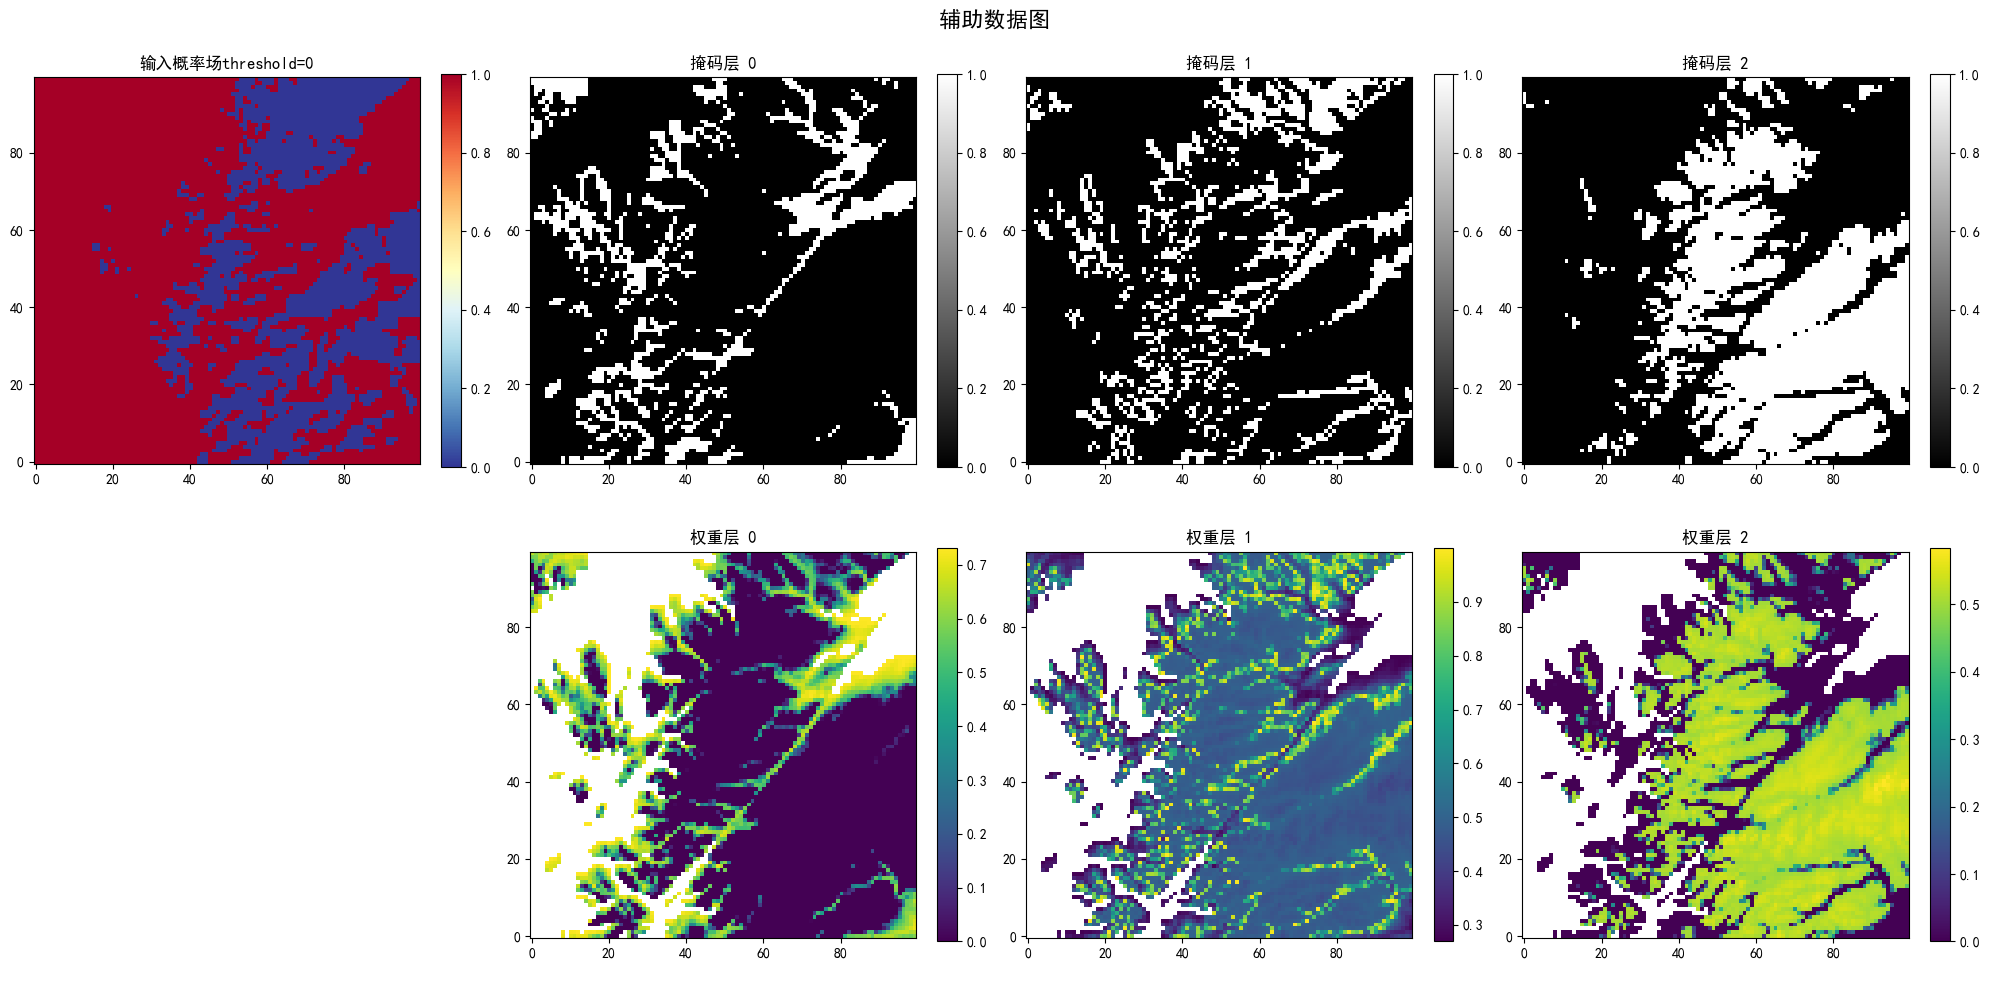

In [5]:
input_data = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d' / "thresholded_input.nc")
mask_data = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d' / "orographic_bands_mask.nc")
weights_data_raw = load_primary(RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d' / "orographic_bands_weights.nc")

plot_auxiliary_data(input_data, mask_data, weights_data_raw, threshold_index=THRESHOLD_INDEX)

In [6]:
# 在调用前打印形状
print("Input data shape:", input_data.shape)           # 预期: (n_threshold, y, x)
print("Mask data shape:", mask_data.shape)             # 预期: (n_mask, y, x)
print("Weights data shape:", weights_data_raw.shape)       # 预期: (n_mask, y, x)

# 选择单个阈值
data_2d = (
    input_data
    .isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0)
    .squeeze(drop=True)
)
print("Data slice shape:", data_2d.shape)           # 预期: (y, x)

Input data shape: (4, 1, 1, 1, 100, 100)
Mask data shape: (3, 100, 100)
Weights data shape: (3, 100, 100)
Data slice shape: (100, 100)


### 3.1 方形邻域折叠结果对比

调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 生成方形邻域结果，并与官方 KGO、原算法结果做统一色标对比。

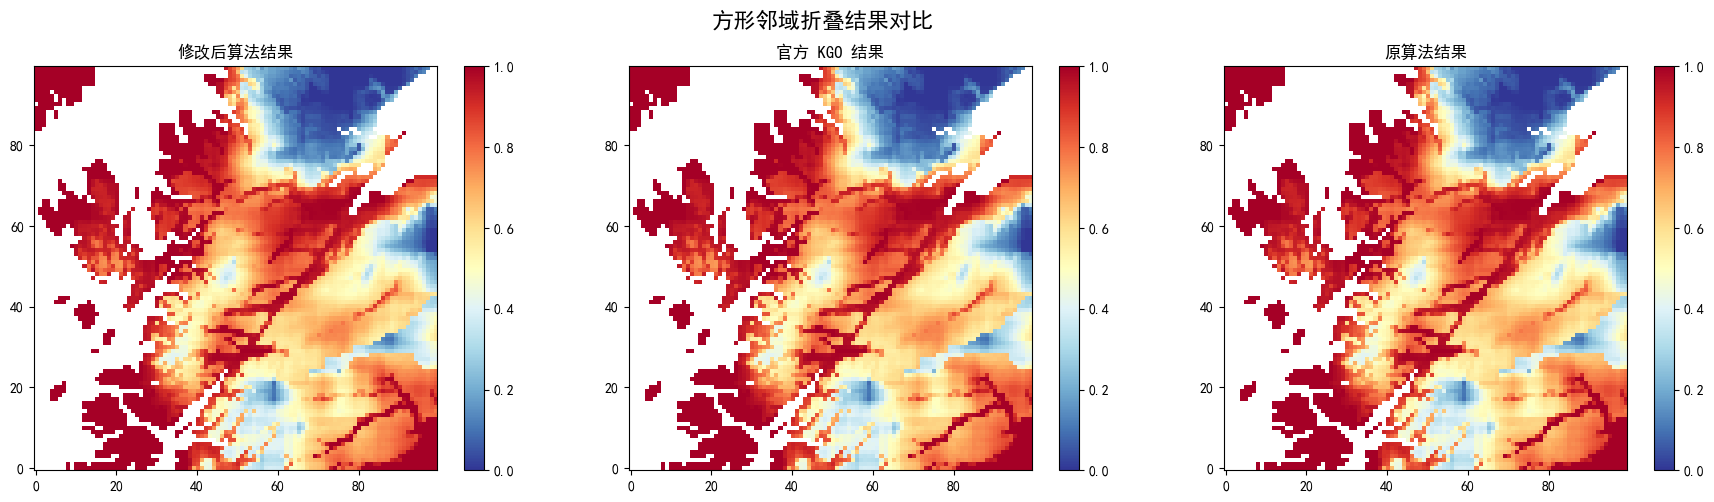

In [7]:
modified_square = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "square",
    RADIUS_METRES,
    collapse_weights=weights_data_raw,
).process(input_data, mask_data)

kgo_square = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "kgo_collapsed.nc"))
original_square = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "original_collapsed.nc"))

plot_result_comparison(
    "方形邻域折叠结果对比",
    modified_square.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
    kgo_square.isel(threshold=THRESHOLD_INDEX).values,
    original_square.isel(threshold=THRESHOLD_INDEX).values,
)


### 3.2 圆形邻域折叠结果对比

调用迁移后的 `ApplyNeighbourhoodProcessingWithAMask` 生成圆形邻域结果，并与官方 KGO、原算法结果做统一色标对比。

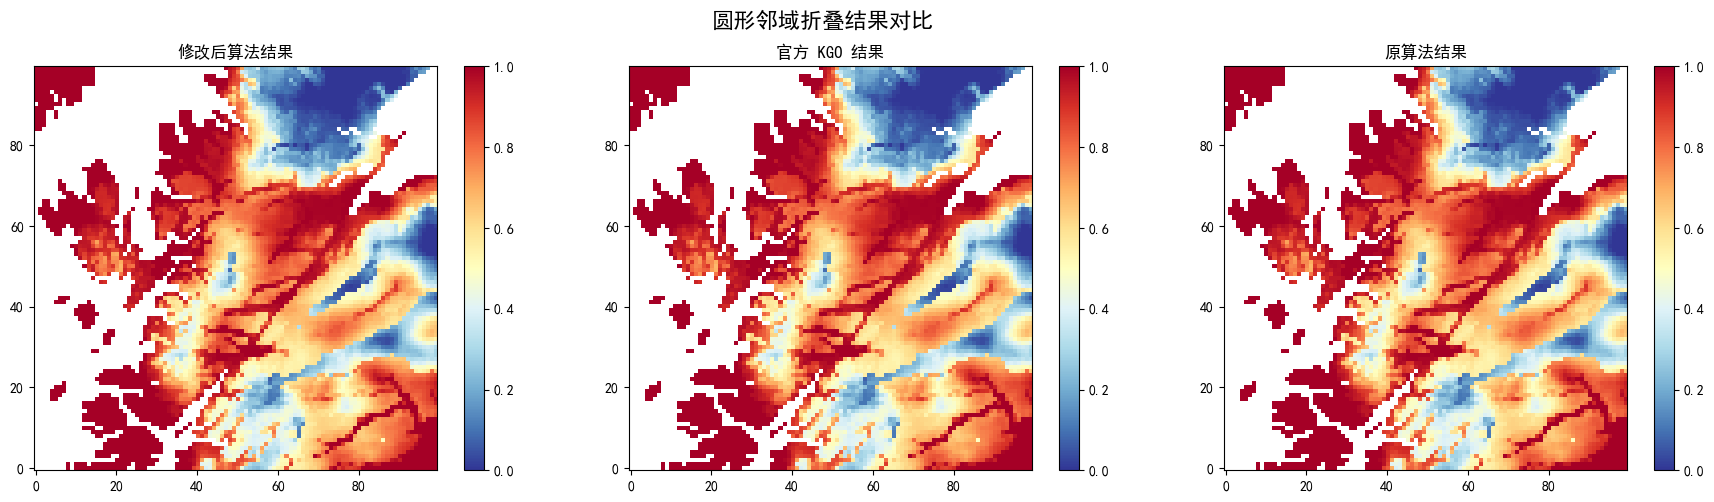

In [8]:
modified_circular = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "circular",
    RADIUS_METRES,
    collapse_weights=weights_data_raw,
).process(input_data, mask_data)

kgo_circular = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "kgo_collapsed_circular.nc"))
original_circular = clean_fill_values(load_primary(RESOURCE_DIR / 'iterate_with_mask' / "basic_collapse_bands" / "original_collapsed_circular.nc"))

plot_result_comparison(
    "圆形邻域折叠结果对比",
    modified_circular.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
    kgo_circular.isel(threshold=THRESHOLD_INDEX).values,
    original_circular.isel(threshold=THRESHOLD_INDEX).values,
)


## 4. 邻域结果不折叠
本节输入不包含地形带权重，结果不会进行折叠。

原算法结果中会新增一个掩码分层维度，修改后算法为限制输出维度将新增维度与原输入member维度进行融合。

In [9]:
#数据读取
input_path = RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d' / 'input.nc'
mask_path = RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d' / 'mask.nc'
kgo_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'kgo_basic.nc'
original_square_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'original_unfolded_result.nc'
original_circular_path = RESOURCE_DIR / 'iterate_with_mask' / "basic" / 'original_unfolded_circular_result.nc'

input_data = load_primary(input_path)
mask_data = load_primary(mask_path)
kgo_data = clean_fill_values(load_primary(kgo_path))
original_unfolded_square = clean_fill_values(load_primary(original_square_path))
original_unfolded_circular = clean_fill_values(load_primary(original_circular_path))

#算法调用
modified_unfolded_square = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "square",
    20000.0,
).process(input_data, mask_data)

modified_unfolded_circular = ApplyNeighbourhoodProcessingWithAMask(
    COORD_FOR_MASKING,
    "circular",
    20000.0,
).process(input_data, mask_data)

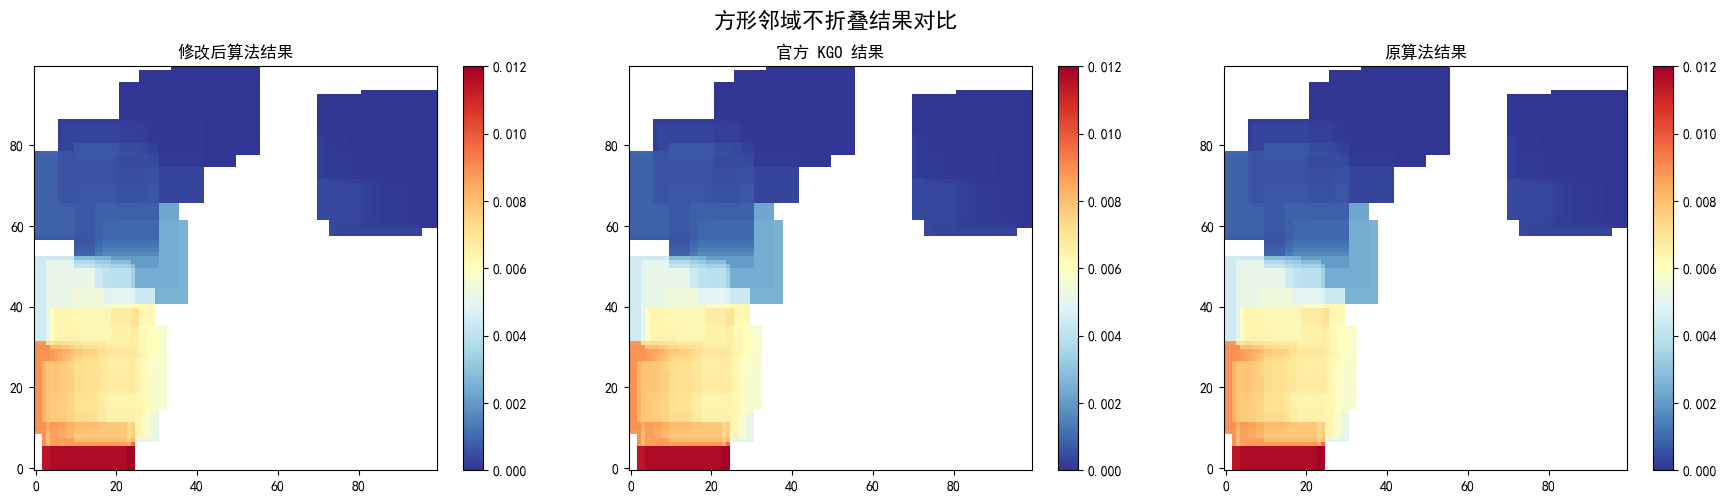

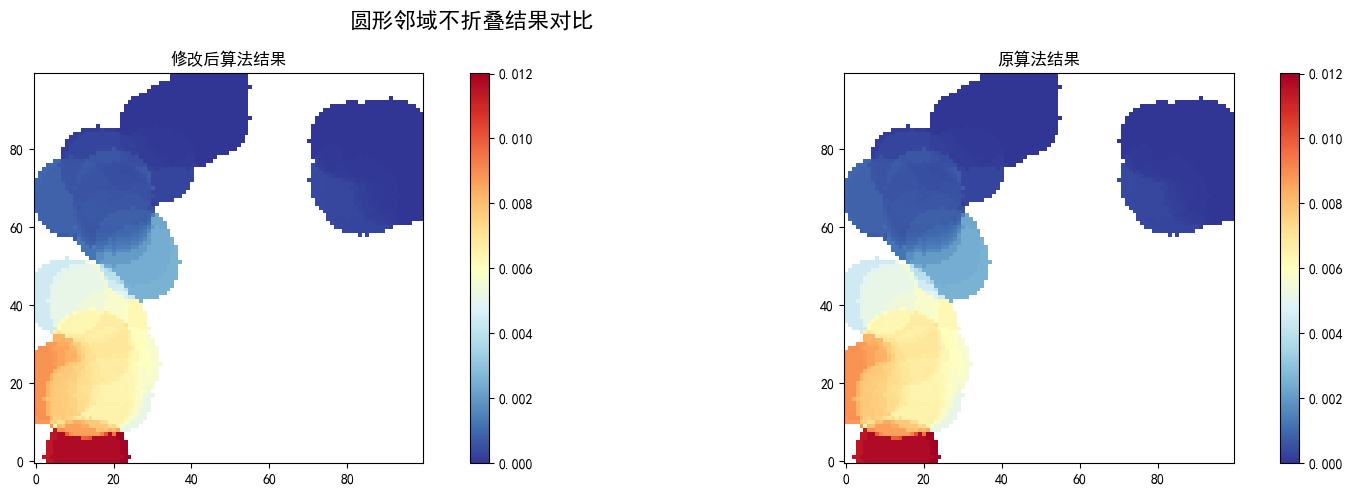

In [10]:
def to_plot_2d_unfolded(da, member_idx=0, zone_idx=0):
    out = da
    for dim in ("member", "threshold", "realization", "level", "time", "dtime"):
        if dim in out.dims:
            out = out.isel({dim: member_idx})
    if "topographic_zone" in out.dims:
        out = out.isel({"topographic_zone": zone_idx})
    out = out.squeeze(drop=True)
    return np.asarray(out.values)

plot_result_comparison(
    "方形邻域不折叠结果对比",
    to_plot_2d_unfolded(modified_unfolded_square, 0, 0),
    to_plot_2d_unfolded(kgo_data, 0, 0),
    to_plot_2d_unfolded(original_unfolded_square, 0, 0),
)

#圆形邻域结果
modified = to_plot_2d_unfolded(modified_unfolded_circular, 0, 0)
original = to_plot_2d_unfolded(original_unfolded_circular, 0, 0)
vmin, vmax = common_limits(modified, original)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
panels = [
    (modified, "修改后算法结果"),
    (original, "原算法结果"),
]
for ax, (data, name) in zip(axes, panels):
    im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("圆形邻域不折叠结果对比", fontsize=16)
fig.tight_layout()
plt.show()


In [11]:
print(original_unfolded_square)

<xarray.DataArray (realization: 3, topographic_zone: 3,
                   projection_y_coordinate: 100, projection_x_coordinate: 100)> Size: 720kB
array([[[[           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         [           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         [           nan,            nan, 1.14261238e-02, ...,
                     nan,            nan,            nan],
         ...,
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan],
         [           nan,            nan,            nan, ...,
                     nan,            nan,            nan]],

        [[1.25218602e-02, 1.24587072e-02, 1.16079869e-02, ...,
          2.84627685e-03, 2.84627685e-03,

In [12]:
print(modified_unfolded_square)

<xarray.DataArray 'thickness_of_rainfall_amount' (member: 9, level: 1, time: 1,
                                                  dtime: 1, lat: 100, lon: 100)> Size: 360kB
array([[[[[[           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           [           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           [           nan,            nan, 1.14261238e-02, ...,
                       nan,            nan,            nan],
           ...,
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan],
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan],
           [           nan,            nan,            nan, ...,
                       nan,            nan,            nan]]]]],




       [[[[[1.25218602e-02, 1.24587072e-02, 1.1

## CLI 应用
ApplyNeighbourhoodProcessingWithAMask 相关示例脚本：
1. `nbhood/cli/ens_nbhood_iterate_with_mask.py`
2. `nbhood/cli/ens_nbhood_land_and_sea.py`

In [13]:
#CLI应用部分通用辅助函数
def _first_2d(da):
    """提取第一个2D切片"""
    out = da
    for dim in ('member', 'threshold', 'realization', 'topographic_zone'):
        if dim in out.dims:
            out = out.isel({dim: 0})
    out = out.squeeze(drop=True)
    return np.asarray(out)

def load_data(path, var_name='air_temperature'):
    """智能加载变量：优先使用指定变量名，未指定时自动选择主变量"""
    try:
        ds = xr.open_dataset(path, engine='netcdf4')
        if var_name in ds.variables:
            return ds[var_name]

        # 自动选择主变量：跳过边界变量和网格映射变量
        for name, da in ds.data_vars.items():
            if name.endswith('_bnds'):
                continue
            if da.ndim == 0 and 'grid_mapping_name' in da.attrs:
                continue
            return ds[name]
        return None
    except Exception:
        return None

def plot_result_comparison(title, cli_modified, cli_original, kgo_reference):
    """绘制修改后算法、KGO 和原算法结果对比图。"""
    cli_orig_2d = _first_2d(cli_original)
    cli_mod_2d = _first_2d(cli_modified)
    kgo_2d = _first_2d(kgo_reference)
    vmin, vmax = common_limits(cli_orig_2d, cli_mod_2d, kgo_2d)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    panels = [
        (cli_mod_2d, "修改后CLI结果"),
        (cli_orig_2d, "原CLI结果"),
        (kgo_2d, "预期结果"),
    ]
    for ax, (data, name) in zip(axes, panels):
        im = ax.imshow(data, origin="lower", cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

### 1. ens_nbhood_iterate_with_mask.py

无权重（方形邻域）示例（脚本默认示例为方形折叠，需调相关参数后运行）：
```powershell
python -m nbhood.cli.ens_nbhood_iterate_with_mask
```

在 Notebook 中调用 `process()`：

```python
from nbhood.cli.ens_nbhood_iterate_with_mask import process

#数据存放路径
base = "./nbhood/test_data/official_test_use_nbhood/iterate_with_mask/normalized_meb6d"
process(
    input_data_path=f"{base}/input.nc", 
    mask_path=f"{base}//mask.nc",
    coord_for_masking="topographic_zone",
    radii=[20000.0],
    output_path=f"{base}/cli_test_unfolded_square_result.nc",
    neighbourhood_shape="square",
)
```

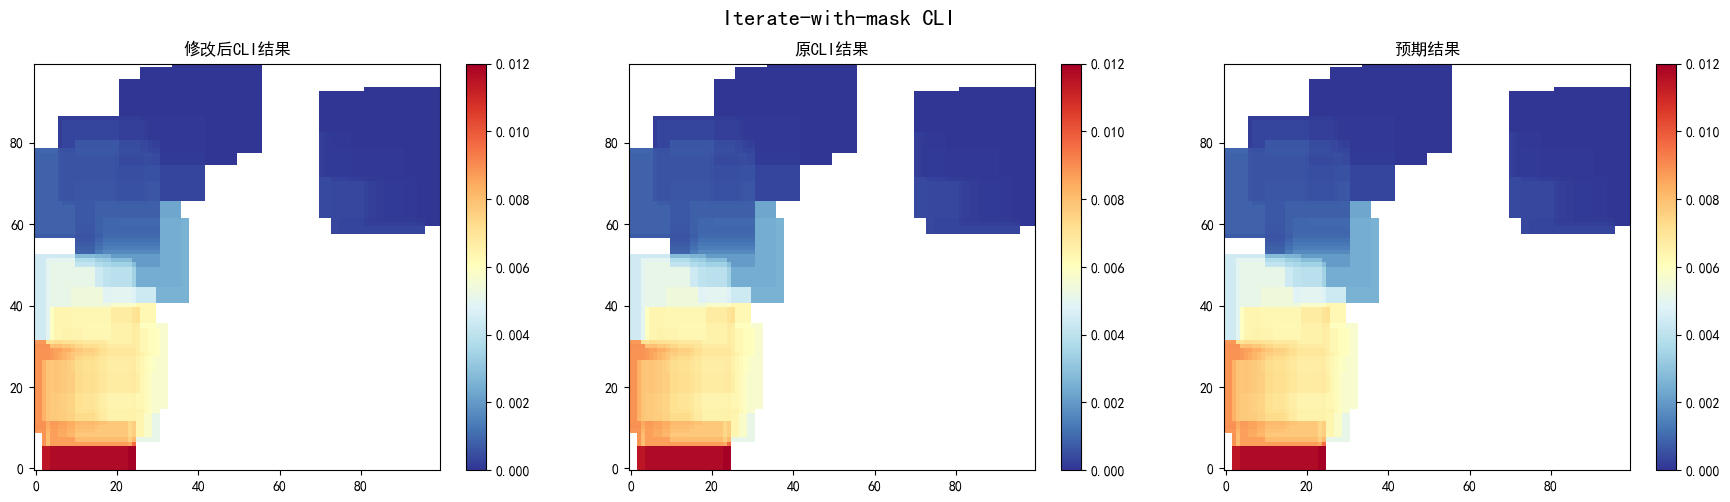

In [14]:
iterate_dir = RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d'

cli_iter_square = load_primary(iterate_dir / 'cli_test_unfolded_square_result.nc')

original_cli_path = RESOURCE_DIR / 'iterate_with_mask' / 'basic' / 'cli_unfolded_square_result.nc'
original_cli_square = clean_fill_values(load_primary(original_cli_path))

plot_result_comparison("Iterate-with-mask CLI", cli_iter_square, original_cli_square, kgo_data)

带权重折叠示例（脚本默认示例为方形折叠，可直接运行）：

```powershell
python -m nbhood.cli.ens_nbhood_iterate_with_mask
```

**圆形邻域折叠**（`process()` 调用）：

```python
from nbhood.cli.ens_nbhood_iterate_with_mask import process

#数据存放路径
base = "./nbhood/test_data/official_test_use_nbhood/iterate_with_mask/normalized_meb6d"
process(
    input_data_path=f"{base}/thresholded_input.nc",
    mask_path=f"{base}/orographic_bands_mask.nc",
    weights_path=f"{base}/orographic_bands_weights.nc",
    coord_for_masking="topographic_zone",
    radii=[10000.0],
    output_path=f"{base}/cli_test_iterated_circular_result.nc",
    neighbourhood_shape="circular",
)
```



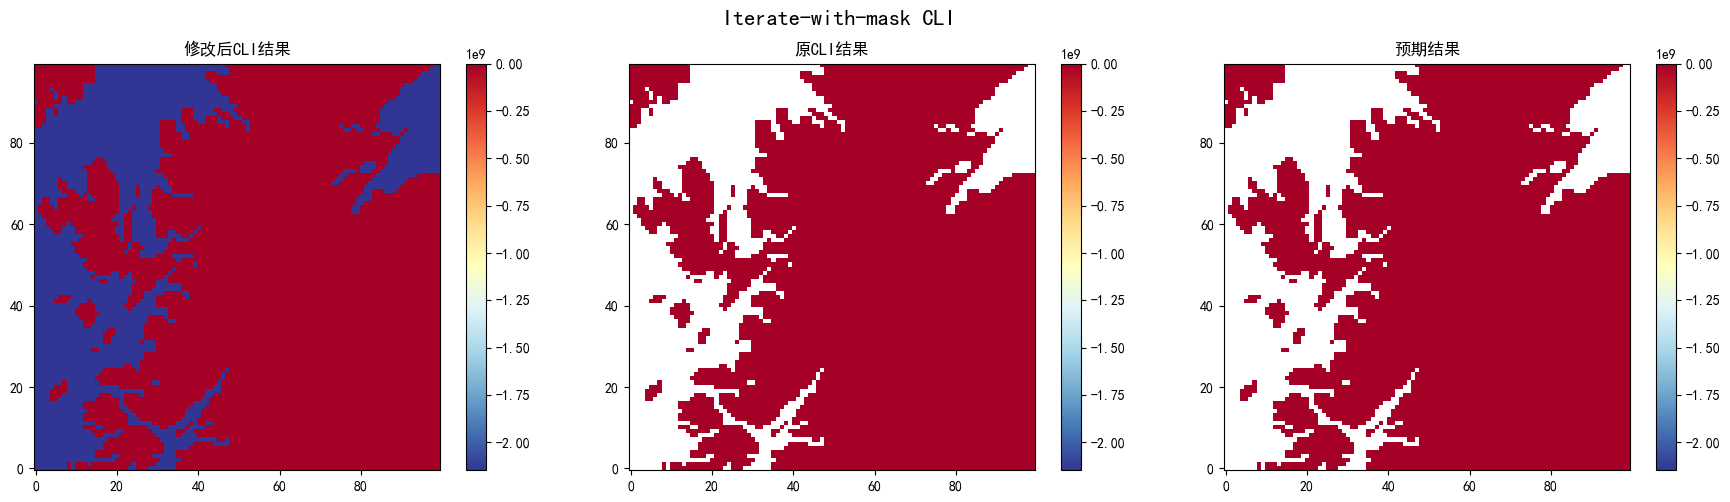

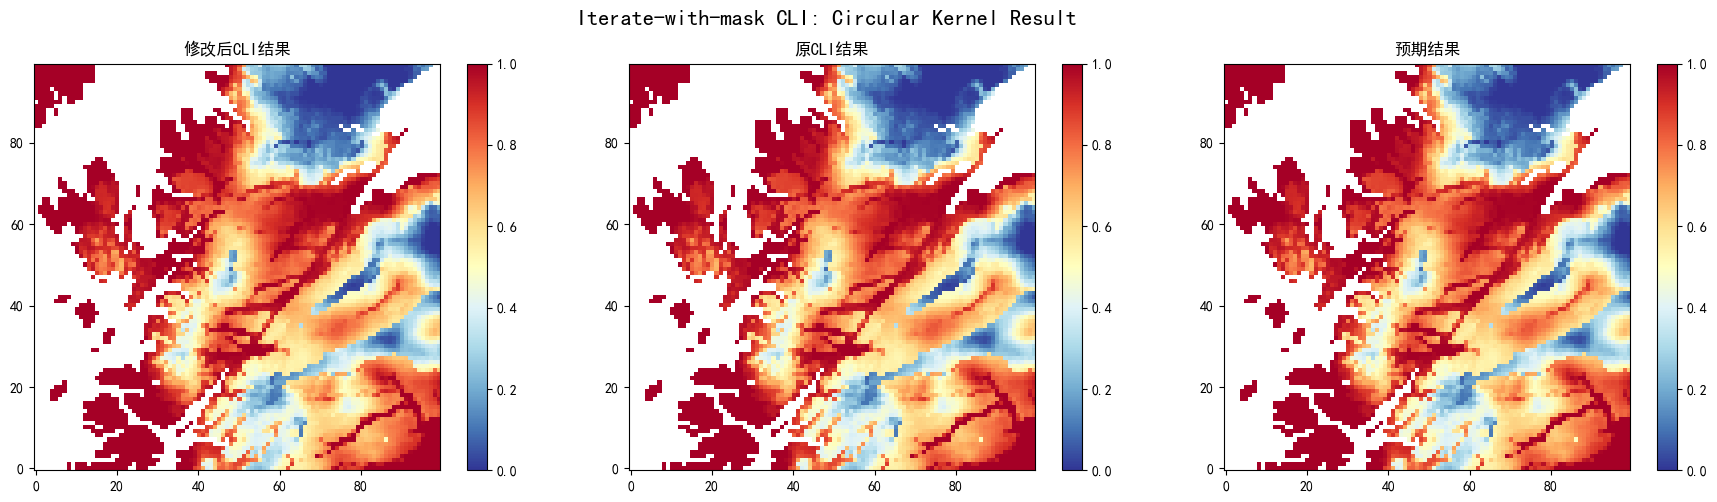

In [15]:
iterate_dir = RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d'

cli_iter_square = load_primary(iterate_dir / 'cli_test_iterated_result.nc')
cli_iter_circular = load_primary(iterate_dir / 'cli_test_iterated_circular_result.nc')

original_cli_path = RESOURCE_DIR / 'iterate_with_mask' / 'basic_collapse_bands' / 'cli_iterated_result.nc'
original_cli_path_circular = RESOURCE_DIR / 'iterate_with_mask' / 'basic_collapse_bands' / 'cli_iterated_circular_result.nc'
original_cli_square = clean_fill_values(load_primary(original_cli_path))
original_cli_circular = clean_fill_values(load_primary(original_cli_path_circular))

plot_result_comparison("Iterate-with-mask CLI", cli_iter_square, original_cli_square, kgo_square)

plot_result_comparison("Iterate-with-mask CLI: Circular Kernel Result", cli_iter_circular, original_cli_circular, kgo_circular)


### 2. ens_nbhood_land_and_sea.py

In [16]:
def _plot_comparison_simple(title, cli_original, cli_modified, kgo_reference):
    """简化对比：只显示原始数据，不显示差异图"""
    cli_orig_2d = _first_2d(cli_original)
    cli_mod_2d = _first_2d(cli_modified)
    kgo_2d = _first_2d(kgo_reference)
    
    # 计算共同范围
    vmin = min(np.nanmin(cli_orig_2d), np.nanmin(cli_mod_2d), np.nanmin(kgo_2d))
    vmax = max(np.nanmax(cli_orig_2d), np.nanmax(cli_mod_2d), np.nanmax(kgo_2d))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 左侧：修改后CLI结果
    im0 = axes[0].imshow(cli_mod_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0].set_title('修改后CLI结果')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, label='温度 (K)')
    
    # 中间：原始CLI结果
    im1 = axes[1].imshow(cli_orig_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[1].set_title('原始CLI结果')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='温度 (K)')
    
    # 右侧：KGO参考结果
    im2 = axes[2].imshow(kgo_2d, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[2].set_title('KGO参考结果')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='温度 (K)')
    
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()
    
    # 打印统计信息
    diff_orig_mod = cli_orig_2d - cli_mod_2d
    diff_orig_kgo = cli_orig_2d - kgo_2d
    diff_mod_kgo = cli_mod_2d - kgo_2d
    
    print(f"\n=== {title} 统计信息 ===")
    print(f"原始CLI vs 修改CLI: RMSE={np.sqrt(np.nanmean(diff_orig_mod**2)):.6f}, Bias={np.nanmean(diff_orig_mod):.6f}")
    print(f"原始CLI vs KGO: RMSE={np.sqrt(np.nanmean(diff_orig_kgo**2)):.6f}, Bias={np.nanmean(diff_orig_kgo):.6f}")
    print(f"修改CLI vs KGO: RMSE={np.sqrt(np.nanmean(diff_mod_kgo**2)):.6f}, Bias={np.nanmean(diff_mod_kgo):.6f}")

#### 2.1 简单陆地-海洋掩膜输入示例

方形邻域（脚本内置默认示例）：

```powershell
python -m nbhood.cli.ens_nbhood_land_and_sea
```

圆形邻域（`process()` 调用）：

```python
from nbhood.cli.ens_nbhood_land_and_sea import process

#数据存放路径
base = "./nbhood/test_data/official_test_use_nbhood/land_and_sea/normalized_meb6d"
process(
    input_data_path=f"{base}/input.nc",
    mask_path=f"{base}/ukvx_landmask.nc",
    radii=[10000.0],
    output_path=f"{base}/cli_test_circular_result.nc",
    neighbourhood_shape="circular",
)
```



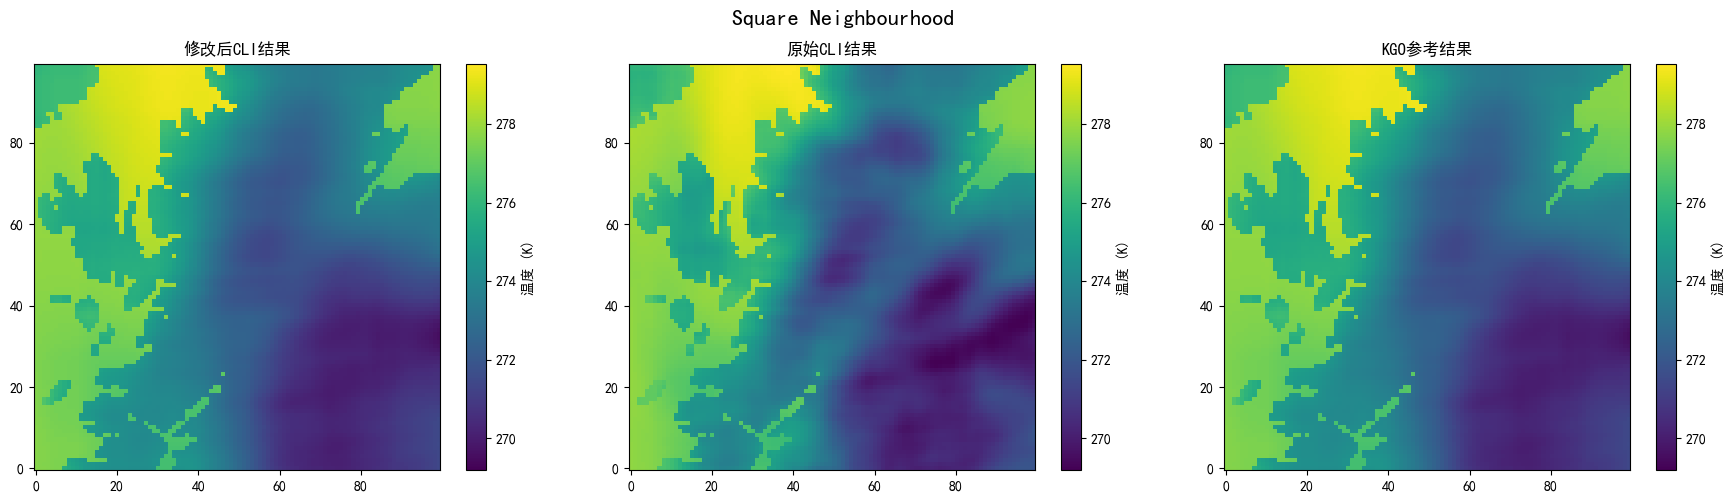


=== Square Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.434819, Bias=0.014689
原始CLI vs KGO: RMSE=0.434817, Bias=0.014674
修改CLI vs KGO: RMSE=0.000290, Bias=-0.000015


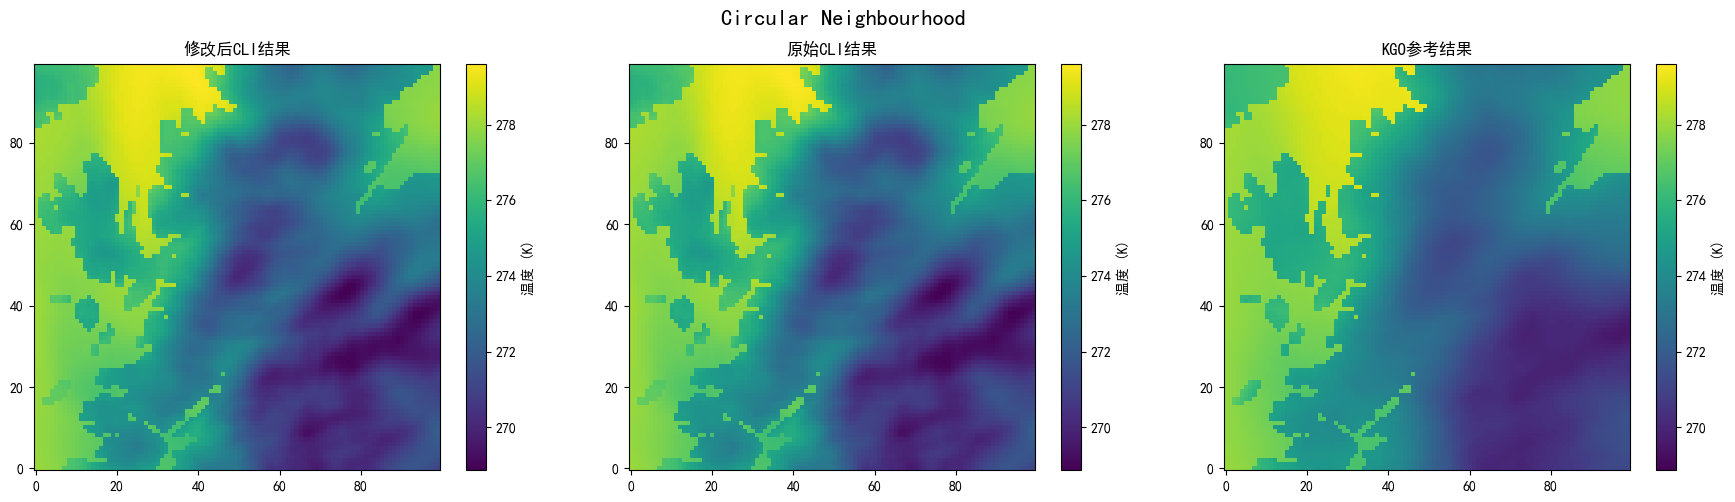


=== Circular Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.454432, Bias=0.007539
修改CLI vs KGO: RMSE=0.454432, Bias=0.007539


In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 路径定义
PROJECT_DIR = Path.cwd().parent
RESOURCE_DIR = PROJECT_DIR / "test_data" / "official_test_use_nbhood"
land_dir = RESOURCE_DIR / 'land_and_sea' / "no_topographic_bands"
land_normalized_dir = RESOURCE_DIR / 'land_and_sea' / 'normalized_meb6d'

# --- 主程序 ---

# 1. 加载方形邻域数据
cli_mod_sq  = load_data(land_normalized_dir / 'cli_test_land_sea_result.nc')
cli_orig_sq = load_data(land_dir / 'cli_land_sea_result.nc')
kgo_sq      = load_data(land_dir / 'kgo.nc')

# 2. 加载圆形邻域数据
cli_orig_ci = load_data(land_dir / 'cli_circular_result.nc')
cli_mod_ci  = load_data(land_normalized_dir / 'cli_test_circular_result.nc')
kgo_ci      = load_data(land_dir / 'kgo_circular.nc')

# 检查是否所有数据都加载成功
if cli_orig_sq is not None and cli_mod_sq is not None and kgo_sq is not None:
    _plot_comparison_simple("Square Neighbourhood", cli_orig_sq, cli_mod_sq, kgo_sq)

if cli_orig_ci is not None and cli_mod_ci is not None and kgo_ci is not None:
    _plot_comparison_simple("Circular Neighbourhood", cli_orig_ci, cli_mod_ci, kgo_ci)

# 加载并显示陆地-海洋掩码
try:
    landmask = xr.open_dataarray(land_normalized_dir / 'ukvx_landmask.nc')
    landmask_2d = _first_2d(landmask)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(landmask_2d, cmap='binary', origin='lower')
    plt.colorbar(label='Land (1) / Sea (0)')
    plt.title('陆地-海洋掩码分布')
    plt.xlabel('X轴')
    plt.ylabel('Y轴')
    plt.tight_layout()
    plt.show()
except Exception as e:
    pass

#### 2.2 地形带掩膜输入示例

方形邻域：

```python
from nbhood.cli.ens_nbhood_land_and_sea import process

#数据存放路径
base = "./nbhood/test_data/official_test_use_nbhood/land_and_sea/normalized_meb6d"
process(
    input_data_path=f"{base}/input.nc",
    mask_path=f"{base}/topographic_bands_land.nc",
    weights_path=f"{base}/weights_land.nc",
    radii=[10000.0],
    output_path=f"{base}/cli_test_topographic_bands_result.nc",
    neighbourhood_shape="square",
)
```

圆形邻域：

```python
process(
    input_data_path=f"{base}/input.nc",
    mask_path=f"{base}/topographic_bands_land.nc",
    weights_path=f"{base}/weights_land.nc",
    radii=[10000.0],
    output_path=f"{base}/cli_test_topographic_bands_circular_result.nc",
    neighbourhood_shape="circular",
)
```

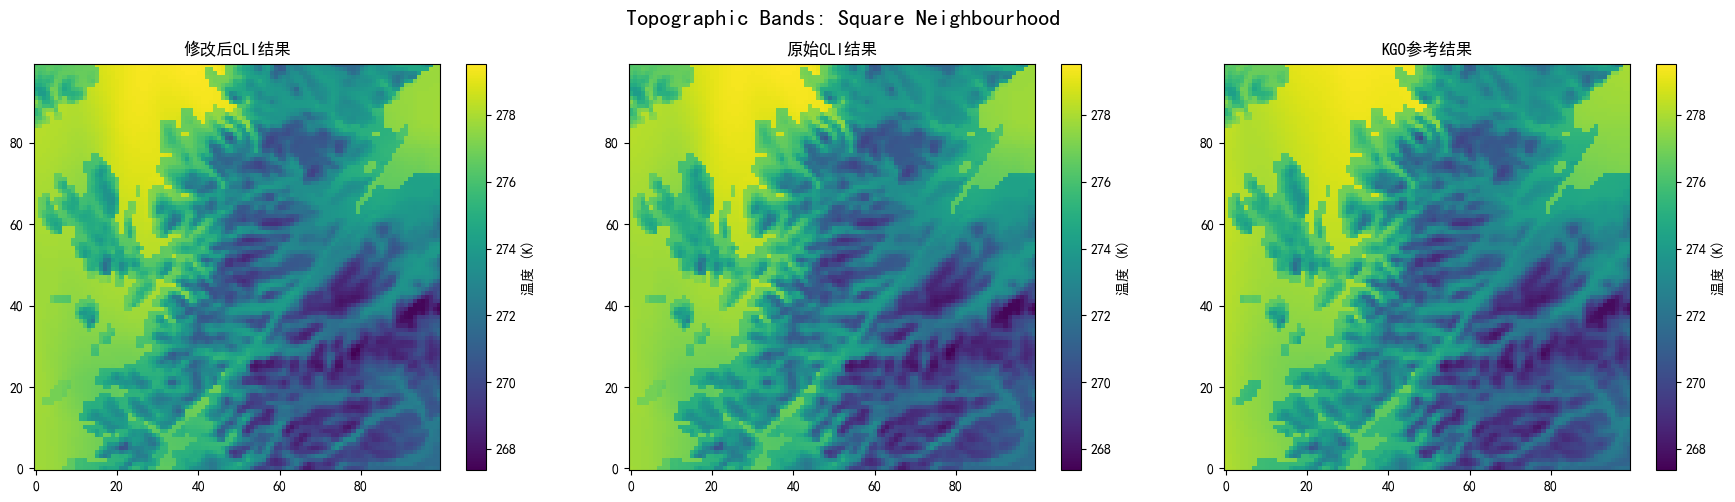


=== Topographic Bands: Square Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.238081, Bias=-0.015664
修改CLI vs KGO: RMSE=0.238081, Bias=-0.015664


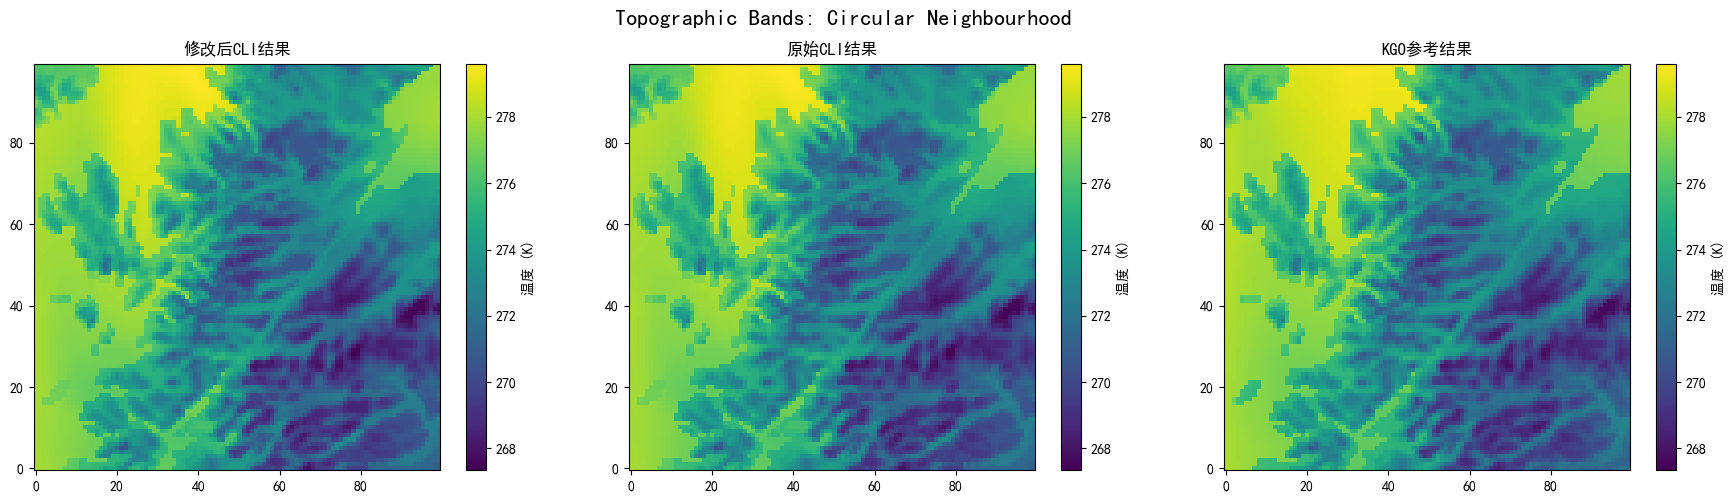


=== Topographic Bands: Circular Neighbourhood 统计信息 ===
原始CLI vs 修改CLI: RMSE=0.000000, Bias=0.000000
原始CLI vs KGO: RMSE=0.283794, Bias=-0.013715
修改CLI vs KGO: RMSE=0.283794, Bias=-0.013715


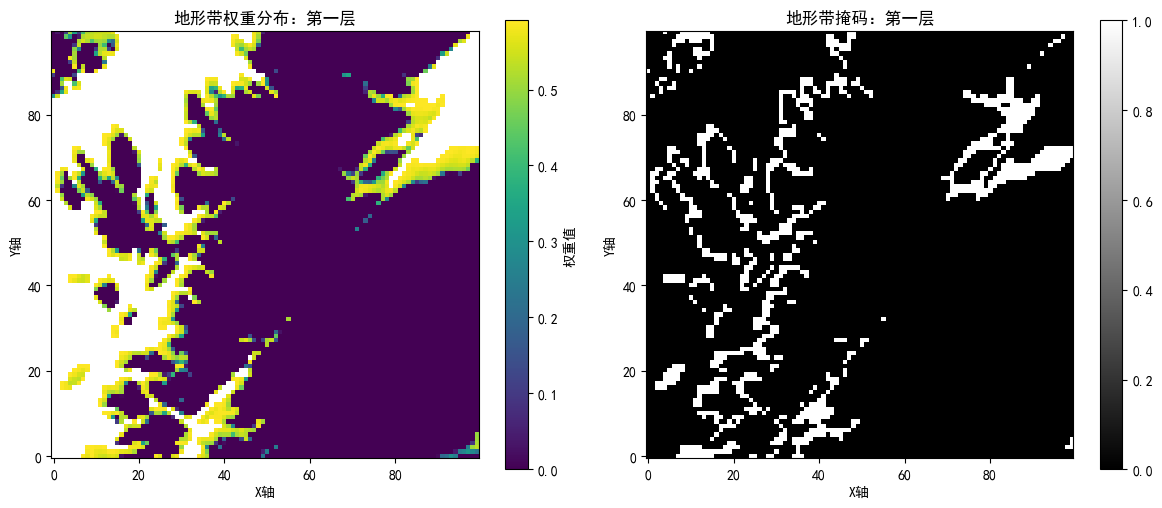

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 路径定义
PROJECT_DIR = Path.cwd().parent
RESOURCE_DIR = PROJECT_DIR / "test_data" / "official_test_use_nbhood"

# 原始CLI结果路径
topo_bands_dir = RESOURCE_DIR / 'land_and_sea' / 'topographic_bands'
# 修改算法CLI结果路径
land_normalized_dir = RESOURCE_DIR / 'land_and_sea' / 'normalized_meb6d'

# --- 主程序：地形带（topographic bands）邻域处理结果对比 ---

# 1. 加载方形邻域数据
cli_orig_sq = load_data(topo_bands_dir / 'cli_topographic_bands_square_result.nc')
cli_mod_sq = load_data(land_normalized_dir / 'cli_test_topographic_bands_result.nc')
kgo_sq = load_data(topo_bands_dir / 'kgo.nc')

# 2. 加载圆形邻域数据
cli_orig_ci = load_data(topo_bands_dir / 'cli_topographic_bands_circular_result.nc')
cli_mod_ci = load_data(land_normalized_dir / 'cli_test_topographic_bands_circular_result.nc')
kgo_ci = load_data(topo_bands_dir / 'kgo_circular.nc')
if kgo_ci is None:
    kgo_ci = kgo_sq  # 如果没有专门的圆形KGO，使用方形的KGO

# 检查并执行对比
if cli_orig_sq is not None and cli_mod_sq is not None and kgo_sq is not None:
    _plot_comparison_simple("Topographic Bands: Square Neighbourhood", cli_orig_sq, cli_mod_sq, kgo_sq)

if cli_orig_ci is not None and cli_mod_ci is not None and kgo_ci is not None:
    _plot_comparison_simple("Topographic Bands: Circular Neighbourhood", cli_orig_ci, cli_mod_ci, kgo_ci)

# 加载并显示地形带权重和掩码
try:
    # 1. 地形带权重
    weights = load_data(land_normalized_dir / 'weights_land.nc', var_name='topographic_zone_weights')
    
    weights_2d = _first_2d(weights)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(weights_2d, cmap='viridis', origin='lower')
    plt.colorbar(label='权重值')
    plt.title('地形带权重分布：第一层')
    plt.xlabel('X轴')
    plt.ylabel('Y轴')
    
    # 2. 地形带掩码
    topo_mask = load_data(land_normalized_dir / 'topographic_bands_land.nc', var_name='topography_mask')
    
    if topo_mask is not None:
        topo_mask_2d = _first_2d(topo_mask)
        
        plt.subplot(1, 2, 2)
        plt.imshow(topo_mask_2d, cmap='gray', origin='lower')
        plt.colorbar()
        plt.title('地形带掩码：第一层')
        plt.xlabel('X轴')
        plt.ylabel('Y轴')
        
        plt.tight_layout()
        plt.show()
except Exception as e:
    pass

## 5. 数据展示

本节只对插件结果做单图展示，便于快速查看 `use_nbhood` 在不同处理路径下生成的二维结果场，不再重复绘制 KGO、原算法或 CLI 对照图。

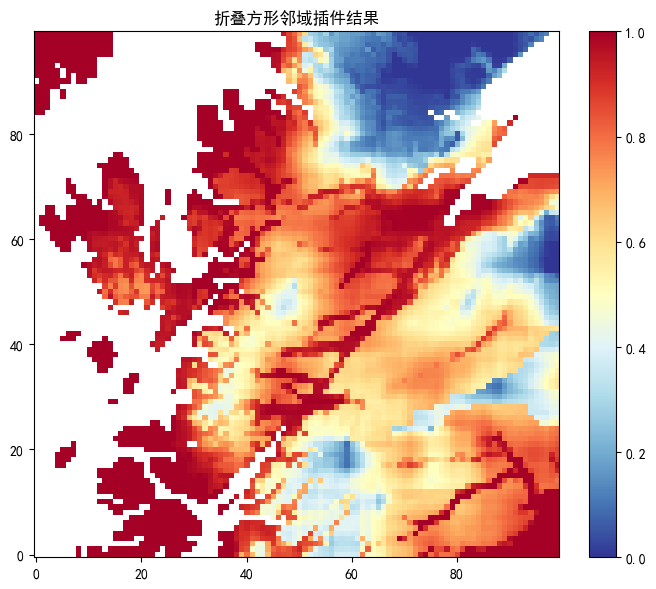

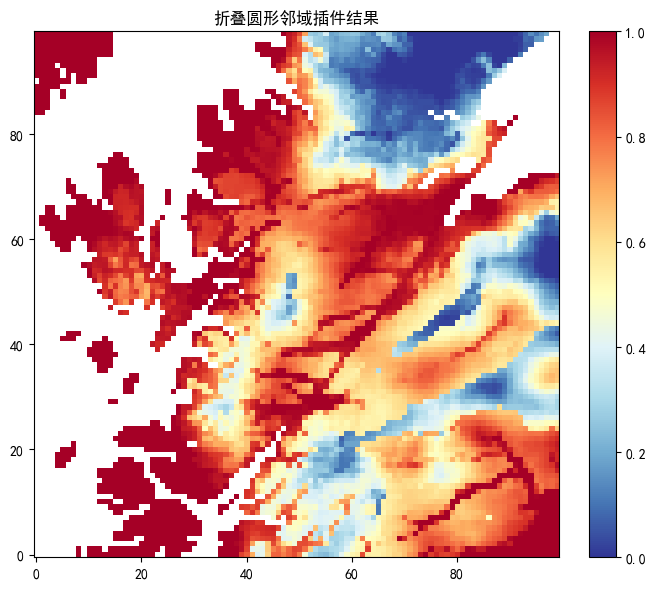

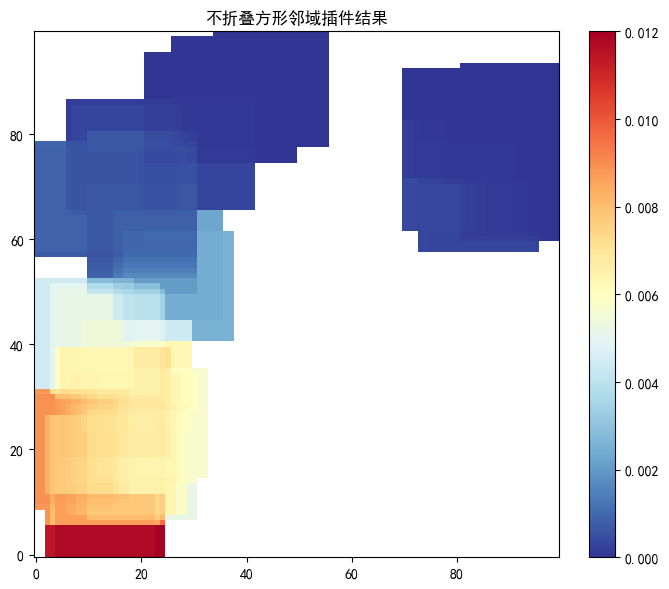

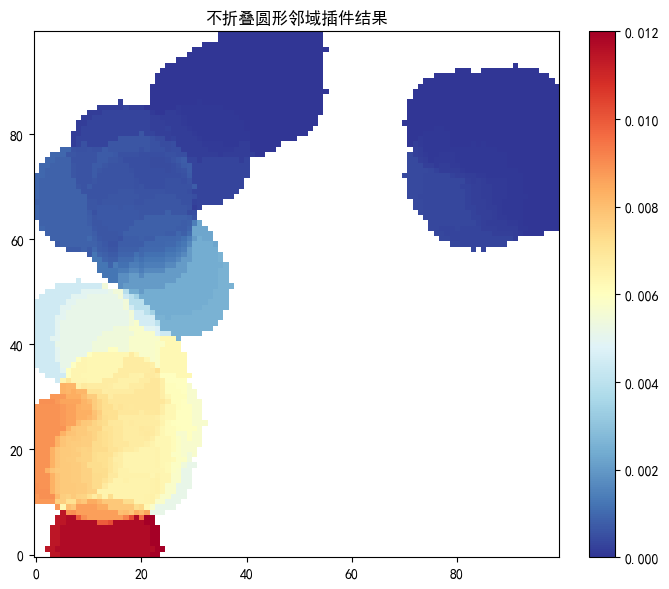

In [19]:
def plot_plugin_field(title, data, cmap="RdYlBu_r"):
    """单独绘制一个插件输出二维场。"""
    values = np.ma.asarray(data)
    plt.figure(figsize=(8, 6))
    plt.imshow(values, origin="lower", cmap=cmap, interpolation="nearest")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.tight_layout()
    plt.show()


collapse_norm_dir = RESOURCE_DIR / 'iterate_with_mask' / 'normalized_meb6d'

if "modified_square" not in globals() or "modified_circular" not in globals():
    collapse_input = load_primary(collapse_norm_dir / 'thresholded_input.nc')
    collapse_mask = load_primary(collapse_norm_dir / 'orographic_bands_mask.nc')
    collapse_weights = load_primary(collapse_norm_dir / 'orographic_bands_weights.nc')

    if "modified_square" not in globals():
        modified_square = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'square',
            RADIUS_METRES,
            collapse_weights=collapse_weights,
        ).process(collapse_input, collapse_mask)

    if "modified_circular" not in globals():
        modified_circular = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'circular',
            RADIUS_METRES,
            collapse_weights=collapse_weights,
        ).process(collapse_input, collapse_mask)

if "modified_unfolded_square" not in globals() or "modified_unfolded_circular" not in globals():
    unfolded_input = load_primary(collapse_norm_dir / 'input.nc')
    unfolded_mask = load_primary(collapse_norm_dir / 'mask.nc')

    if "modified_unfolded_square" not in globals():
        modified_unfolded_square = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'square',
            RADIUS_METRES,
        ).process(unfolded_input, unfolded_mask)

    if "modified_unfolded_circular" not in globals():
        modified_unfolded_circular = ApplyNeighbourhoodProcessingWithAMask(
            COORD_FOR_MASKING,
            'circular',
            RADIUS_METRES,
        ).process(unfolded_input, unfolded_mask)

plot_plugin_field(
    '折叠方形邻域插件结果',
    modified_square.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
)
plot_plugin_field(
    '折叠圆形邻域插件结果',
    modified_circular.isel(member=THRESHOLD_INDEX, level=0, time=0, dtime=0).values,
)
plot_plugin_field(
    '不折叠方形邻域插件结果',
    to_plot_2d_unfolded(modified_unfolded_square, 0, 0),
)
plot_plugin_field(
    '不折叠圆形邻域插件结果',
    to_plot_2d_unfolded(modified_unfolded_circular, 0, 0),
)